<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
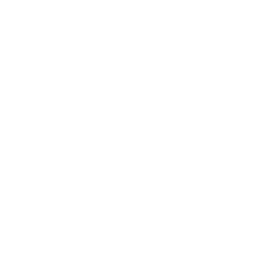
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Klasyfikacja podtypów molekularnych na podstawie ekspresji genów</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biotechnologia / Onkologia genomowa &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Podsumowanie zarządcze

Klasyfikacja próbek biopsji guza do czterech podtypów molekularnych (Luminal-A, Luminal-B, HER2-enriched, Basal-like) przy użyciu paneli biomarkerów ekspresji genów. Zastosowanie kanonicznej analizy dyskryminacyjnej w celu redukcji wysokowymiarowej przestrzeni ekspresji do interpretowalnych osi zmienności. Wykorzystanie MANOVA do sprawdzenia, czy średnie profile ekspresji różnią się istotnie między podtypami. Walidacja krzyżowa w celu oszacowania wiarygodności klasyfikacji na potrzeby wspomagania decyzji klinicznych przy wyborze ścieżki leczenia.

## Źródła danych

| Źródło | Opis | Rekordy |
|--------|-------------|--------|
| WORK.GENE_EXPR | Ekspresja genów guza z etykietami podtypów | 100 |
| WORK.NEW_BIOPSIES | Niesklasyfikowane próbki biopsji | 100 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic gene expression dataset
   with four molecular subtypes
   -------------------------------------------------------- */
DANE work.gene_expr;
    CALL streaminit(42);
    DŁUGOŚĆ mol_subtype $12;
    TABLICA subtype_list[4] $12 _temporary_ ('LUMINAL_A' 'LUMINAL_B' 'HER2_ENRICH' 'BASAL_LIKE');
    POWTÓRZ sample_id = 1 TO 100;
        tumor_id = cat('TUM-', ZAPISZ(sample_id, z5.));
        sub_idx = int(rand('uniform') * 4) + 1;
        mol_subtype = subtype_list[sub_idx];

        /* Simulated gene expression markers (log2 scale) */
        WYBIERZ (mol_subtype);
            GDY ('LUMINAL_A') POWTÓRZ;
                esr1_expr = round(rand('normal', 11.5, 1.2), 0.01);
                pgr_expr = round(rand('normal', 9.8, 1.5), 0.01);
                erbb2_expr = round(rand('normal', 7.2, 0.9), 0.01);
                ki67_expr = round(rand('normal', 6.0, 1.0), 0.01);
                egfr_expr = round(rand('normal', 6.5, 1.1), 0.01);
                cytokeratin5 = round(rand('normal', 5.0, 0.8), 0.01);
                tp53_mut_load = round(rand('poisson', 1.5), 1);
                prolif_score = round(rand('normal', 3.2, 0.8), 0.01);
            KONIEC;
            GDY ('LUMINAL_B') POWTÓRZ;
                esr1_expr = round(rand('normal', 10.0, 1.4), 0.01);
                pgr_expr = round(rand('normal', 7.5, 1.8), 0.01);
                erbb2_expr = round(rand('normal', 8.5, 1.2), 0.01);
                ki67_expr = round(rand('normal', 8.5, 1.2), 0.01);
                egfr_expr = round(rand('normal', 7.0, 1.0), 0.01);
                cytokeratin5 = round(rand('normal', 5.5, 0.9), 0.01);
                tp53_mut_load = round(rand('poisson', 3.0), 1);
                prolif_score = round(rand('normal', 6.0, 1.0), 0.01);
            KONIEC;
            GDY ('HER2_ENRICH') POWTÓRZ;
                esr1_expr = round(rand('normal', 6.5, 1.5), 0.01);
                pgr_expr = round(rand('normal', 5.0, 1.2), 0.01);
                erbb2_expr = round(rand('normal', 13.0, 1.0), 0.01);
                ki67_expr = round(rand('normal', 9.0, 1.3), 0.01);
                egfr_expr = round(rand('normal', 8.5, 1.2), 0.01);
                cytokeratin5 = round(rand('normal', 6.0, 1.0), 0.01);
                tp53_mut_load = round(rand('poisson', 5.0), 1);
                prolif_score = round(rand('normal', 7.5, 1.1), 0.01);
            KONIEC;
            GDY ('BASAL_LIKE') POWTÓRZ;
                esr1_expr = round(rand('normal', 4.5, 1.3), 0.01);
                pgr_expr = round(rand('normal', 3.8, 1.0), 0.01);
                erbb2_expr = round(rand('normal', 6.0, 1.1), 0.01);
                ki67_expr = round(rand('normal', 10.5, 1.4), 0.01);
                egfr_expr = round(rand('normal', 11.0, 1.3), 0.01);
                cytokeratin5 = round(rand('normal', 10.5, 1.2), 0.01);
                tp53_mut_load = round(rand('poisson', 7.0), 1);
                prolif_score = round(rand('normal', 8.8, 1.2), 0.01);
            KONIEC;
            INACZEJ;
        KONIEC;
        WYJŚCIE;
    KONIEC;
    USUŃ sub_idx;
    ETYKIETA mol_subtype='Podtyp molekularny'
        esr1_expr='Ekspresja ESR1 (log2)'
        pgr_expr='Ekspresja PGR (log2)'
        erbb2_expr='Ekspresja ERBB2 (log2)'
        ki67_expr='Ekspresja Ki-67 (log2)'
        egfr_expr='Ekspresja EGFR (log2)'
        cytokeratin5='Cytokeratyna 5 (log2)'
        tp53_mut_load='Obciążenie mutacyjne TP53'
        prolif_score='Wskaźnik proliferacji';
WYKONAJ;


NOTE: DATA work.gene_expr


NOTE: Wrote work.gene_expr (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Generate unclassified biopsy samples
   -------------------------------------------------------- */
DANE work.new_biopsies;
    CALL streaminit(55);
    POWTÓRZ sample_id = 5001 TO 5100;
        tumor_id = cat('TUM-', ZAPISZ(sample_id, z5.));
        esr1_expr = round(rand('normal', 8.0, 3.0), 0.01);
        pgr_expr = round(rand('normal', 6.5, 3.0), 0.01);
        erbb2_expr = round(rand('normal', 8.5, 2.5), 0.01);
        ki67_expr = round(rand('normal', 8.0, 2.0), 0.01);
        egfr_expr = round(rand('normal', 8.0, 2.0), 0.01);
        cytokeratin5 = round(rand('normal', 7.0, 2.5), 0.01);
        tp53_mut_load = round(rand('poisson', 4.0), 1);
        prolif_score = round(rand('normal', 6.0, 2.5), 0.01);
        mol_subtype = '';
        WYJŚCIE;
    KONIEC;
WYKONAJ;


NOTE: DATA work.new_biopsies


NOTE: Wrote work.new_biopsies (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

                                             Rozkład podtypów molekularnych                                             

                                                   The FREQ Procedure

Podtyp molekularny    Frequency    Percent
-------------------------------------------
BASAL_LIKE                   24     24.00
HER2_ENRICH                  22     22.00
LUMINAL_A                    25     25.00
LUMINAL_B                    29     29.00
                               Podsumowanie ekspresji genów według podtypu molekularnego                                

                                                  The MEANS Procedure

                                  Analysis Variable : esr1_expr Ekspresja ESR1 (log2)

        Podtyp molekularny          N Obs           Mean        Std Dev
        ---------------------------------------------------------------
        BASAL_LIKE                     24      4.5479167      1.2257100
        HER2_ENRICH                    22      7.1318182


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mol_subtype.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


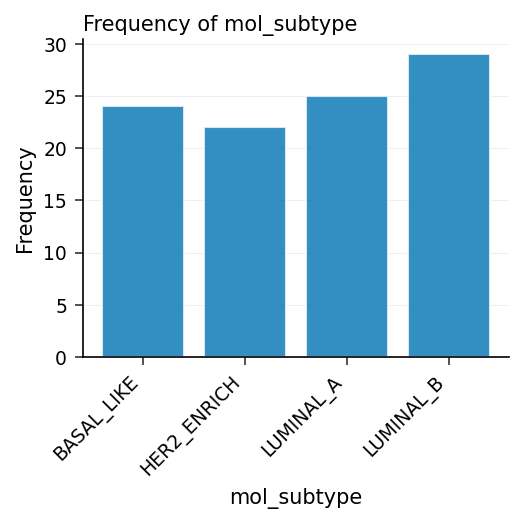

In [3]:
/* --------------------------------------------------------
   Baseline subtype distribution and expression profiles
   -------------------------------------------------------- */
PROCEDURA CZĘSTOŚCI DANE=work.gene_expr;
    TABLES mol_subtype / nocum;
    TYTUŁ 'Rozkład podtypów molekularnych';
WYKONAJ;

PROCEDURA ŚREDNIE DANE=work.gene_expr n mean std;
    KLASA mol_subtype;
    ZMIENNA esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    TYTUŁ 'Podsumowanie ekspresji genów według podtypu molekularnego';
WYKONAJ;

---

In [4]:
/* --------------------------------------------------------
   Canonical discriminant analysis with MANOVA
   CANONICAL extracts discriminant axes for visualization.
   MANOVA tests overall mean separation across subtypes.
   -------------------------------------------------------- */
PROCEDURA DISCRIM DANE=work.gene_expr
        METHOD=NORMAL
        pool=TEST
        canonical
        MANOVA
        crossvalidate
        out=work.subtype_canonical
        OUTSTAT=work.subtype_stats;
    KLASA mol_subtype;
    ZMIENNA esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    TYTUŁ 'Kanoniczna analiza dyskryminacyjna: podtypy molekularne guza';
    title2 'Test MANOVA różnic średnich profili ekspresji';
WYKONAJ;

                               Podsumowanie ekspresji genów według podtypu molekularnego                                


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Cross-Validation Error Rate: 0.0400
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: Multivariate Statistics:
NOTE:   Wilks' Lambda: 0.0037 (p = 0.000000)
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


---

                               Podsumowanie ekspresji genów według podtypu molekularnego                                




NOTE: PROC SGPLOT data=work.subtype_canonical

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


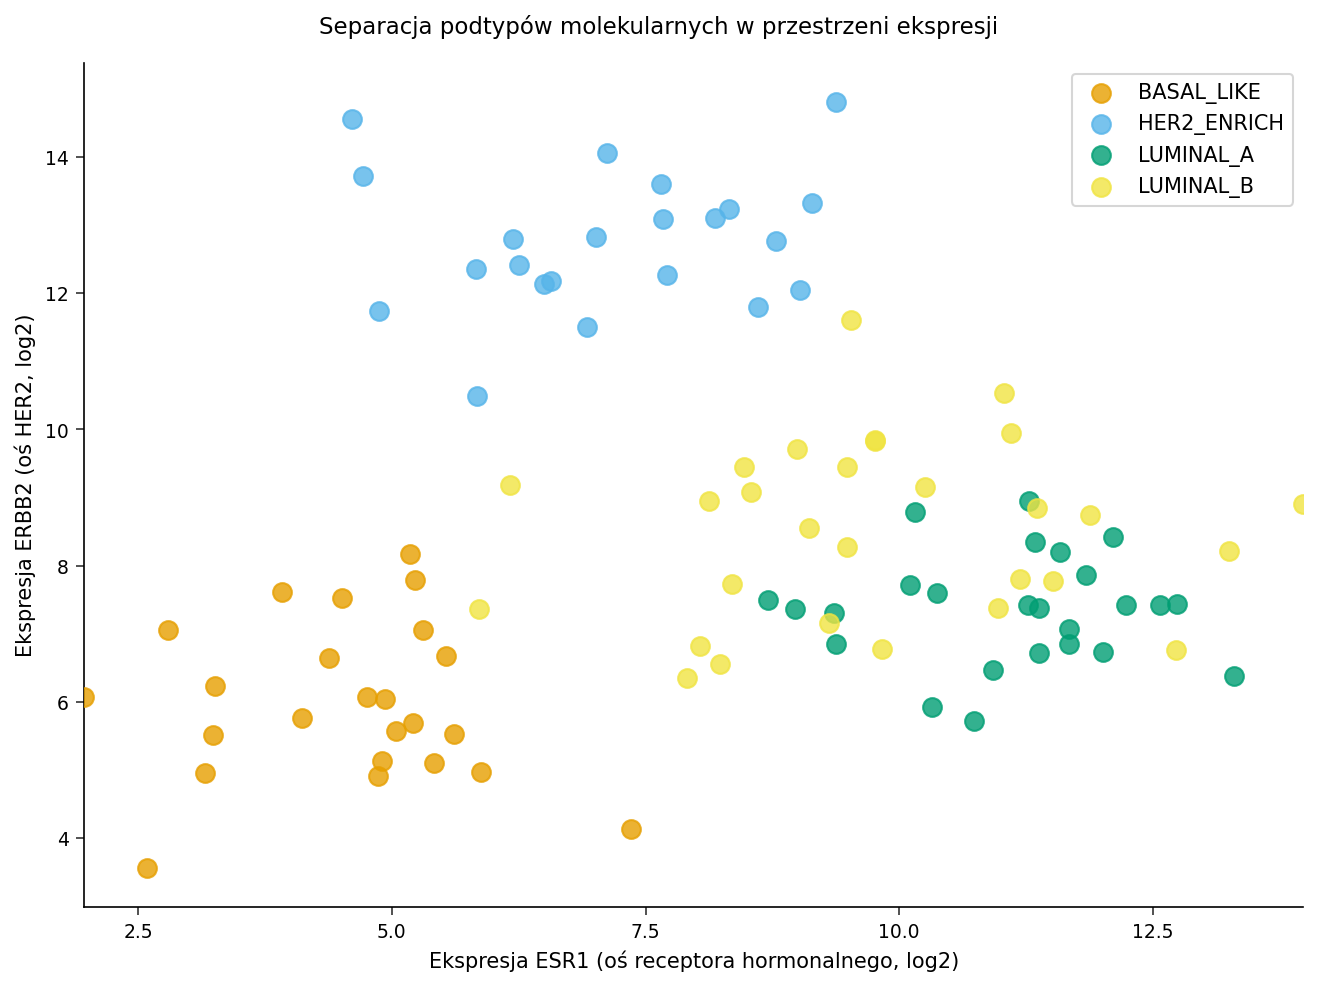

In [5]:
/* --------------------------------------------------------
   Subtype separation in expression space
   ESR1 (hormone-receptor axis) vs ERBB2 (HER2 axis),
   drawn from the discriminant OUT= dataset.
   -------------------------------------------------------- */
PROCEDURA SGPLOT DANE=work.subtype_canonical;
    SCATTER x=esr1_expr y=erbb2_expr / GROUP=mol_subtype
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.2;
    XAXIS ETYKIETA='Ekspresja ESR1 (oś receptora hormonalnego, log2)';
    YAXIS ETYKIETA='Ekspresja ERBB2 (oś HER2, log2)';
    TYTUŁ 'Separacja podtypów molekularnych w przestrzeni ekspresji';
WYKONAJ;


In [6]:
/* --------------------------------------------------------
   Classify untyped biopsy samples
   -------------------------------------------------------- */
PROCEDURA DISCRIM DANE=work.gene_expr
        testdata=work.new_biopsies
        testout=work.classified_biopsies
        METHOD=NORMAL
        pool=TEST
        canonical;
    KLASA mol_subtype;
    ZMIENNA esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    TYTUŁ 'Klasyfikacja podtypów molekularnych nowych biopsji';
WYKONAJ;

                               Podsumowanie ekspresji genów według podtypu molekularnego                                


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


                               Przewidywany rozkład podtypów molekularnych: nowe biopsje                                

                                                   The FREQ Procedure

_INTO_         Frequency    Percent
------------------------------------
BASAL_LIKE             7      7.00
HER2_ENRICH           47     47.00
LUMINAL_A             10     10.00
LUMINAL_B             36     36.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq__into_.spec.json
NOTE: PROC FREQ statement used.


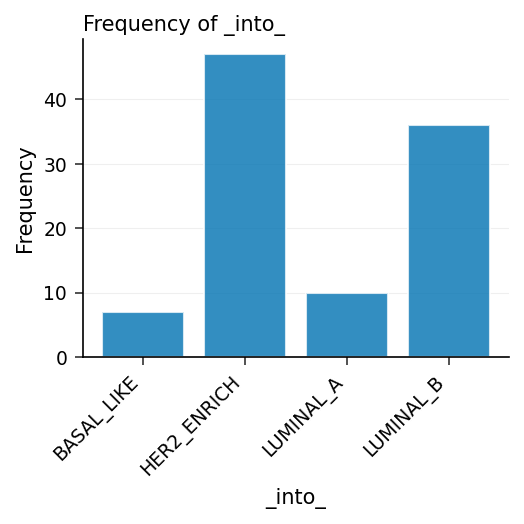

In [7]:
/* --------------------------------------------------------
   Classification distribution for new biopsies
   -------------------------------------------------------- */
PROCEDURA CZĘSTOŚCI DANE=work.classified_biopsies;
    TABLES _into_ / nocum;
    TYTUŁ 'Przewidywany rozkład podtypów molekularnych: nowe biopsje';
WYKONAJ;

---

### Interpretacja

Test MANOVA potwierdza wysoce istotną różnicę średnich profili ekspresji genów między czterema podtypami molekularnymi: lambda Wilksa = 0.0037 przy p < 0.0001, więc podtypy zajmują wyraźnie odrębne obszary ośmiomarkerowej przestrzeni ekspresji. Ta separacja jest widoczna na wykresie rozrzutu w przestrzeni ekspresji, gdzie guzy Luminal leżą wysoko na osi ESR1 (receptor hormonalny), guzy HER2-enriched wypychają się na szczyt osi ERBB2, a guzy Basal-like opadają w dolno-lewy róg obu osi. Klasyfikacja metodą resubstytucji dla 100 oznaczonych guzów jest bezbłędna (0% błędu pozornego), a walidacja krzyżowa leave-one-out ustala poziom błędu na zaledwie 4% — uczciwą dokładność 96% w walidacji krzyżowej, przy poprawnym odtworzeniu każdego podtypu w macierzy pomyłek walidacji krzyżowej. Zastosowanie wytrenowanego klasyfikatora do 100 nieoznaczonych biopsji przypisuje 47 do HER2-enriched, 36 do Luminal-B, 10 do Luminal-A i 7 do Basal-like; przewaga HER2-enriched odzwierciedla podwyższone odczyty ERBB2 i proliferacji w panelu biopsji. Te przypisania podtypów sterują wyborem ścieżki leczenia: terapia hormonalna dla guzów Luminal, ukierunkowane leki anty-HER2 dla grupy HER2-enriched oraz schematy chemioterapii dla guzów Basal-like.

---

In [8]:
/* --------------------------------------------------------
   Export classified biopsies for treatment planning
   -------------------------------------------------------- */
PROCEDURA EKSPORTUJ DANE=work.classified_biopsies
    OUTFILE='classified_biopsy_subtypes.csv'
    DBMS=csv REPLACE;
WYKONAJ;

PROCEDURA EKSPORTUJ DANE=work.subtype_canonical
    OUTFILE='canonical_subtype_scores.csv'
    DBMS=csv REPLACE;
WYKONAJ;


NOTE: PROC EXPORT data=work.classified_biopsies outfile=classified_biopsy_subtypes.csv

NOTE: Exported 100 rows to classified_biopsy_subtypes.csv.
NOTE: PROC EXPORT data=work.subtype_canonical outfile=canonical_subtype_scores.csv

NOTE: Exported 100 rows to canonical_subtype_scores.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Napędzane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>